# 8.2 — Volatilidad local: la fórmula de Dupire

Dado un continuo de precios de vainilla europea $C(K,T)$ (equivalentemente, una
superficie de vol implícita completa), la fórmula de **Dupire** (1994) extrae la única
función determinista $\sigma_{loc}(S,t)$ tal que un modelo de un factor
$dS_t=S_t\,\sigma_{loc}(S_t,t)\,dW_t$ reproduce EXACTAMENTE esos precios de mercado —
distinto de Black-Scholes (vol constante) y de los modelos de vol estocástica (M8.3+),
donde la vol es un proceso adicional.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import svi_total_variance
from qflib.black import bs_price
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)
F0 = 100.0  # r=q=0 en todo el notebook -- el forward es constante -- aisla el mecanismo de Dupire
            # de cualquier ajuste de deriva, que ya se cubrio en 9.1-9.2 (FX) por separado

## 1. La fórmula de Dupire

En precios: $\displaystyle \sigma_{loc}^2(K,T) = \frac{\partial_T C + (r-q)K\,\partial_K C + qC}{\frac12 K^2\,\partial_{KK}C}$
— se cita el resultado (deriva de la ecuación forward de Kolmogorov/Fokker-Planck para
la densidad risk-neutral de $S_T$; la rederivación completa excede el alcance de este
notebook).

Es numéricamente más estable trabajar en **total variance** $w(k,T)=\sigma^2(k,T)T$ sobre
el log-moneyness $k=\ln(K/F_T)$ (evita la resta casi-cancelada de segundas diferencias de
precios). La forma equivalente de Gatheral:
$$\sigma_{loc}^2(k,T) = \frac{\partial_T w}{1-\frac{k}{w}\partial_k w+\frac14\left(-\frac14-\frac1w+\frac{k^2}{w^2}\right)(\partial_k w)^2+\frac12\partial_{kk}w}$$

**Control de sanidad inmediato**: si $w(k,T)=\sigma_0^2 T$ (superficie plana, sin smile),
$\partial_k w=\partial_{kk}w=0$, el denominador colapsa a 1 y $\sigma_{loc}^2=\partial_T w=\sigma_0^2$
— Dupire recupera la vol constante de Black-Scholes, como debe ser.

In [2]:
def durrleman_denominator(k, w_func, dk=1e-3, dT=1e-4, T=None):
    '''Denominador de Dupire en total variance (Seccion 1). w_func(k,T) -> w escalar/array en k.'''
    w0 = w_func(k, T)
    if T > 2 * dT:
        wT = (w_func(k, T + dT) - w_func(k, T - dT)) / (2 * dT)
    else:
        wT = (w_func(k, T + dT) - w0) / dT  # una sola cara cerca de T~0
    wk = (w_func(k + dk, T) - w_func(k - dk, T)) / (2 * dk)
    wkk = (w_func(k + dk, T) - 2 * w0 + w_func(k - dk, T)) / dk ** 2
    denom = 1.0 - (k / w0) * wk + 0.25 * (-0.25 - 1.0 / w0 + k ** 2 / w0 ** 2) * wk ** 2 + 0.5 * wkk
    return wT, denom


def dupire_local_variance(k, T, w_func, dk=1e-3, dT=1e-4):
    wT, denom = durrleman_denominator(k, w_func, dk=dk, dT=dT, T=T)
    return wT / denom


# control de sanidad: superficie plana -- Dupire debe devolver exactamente sigma0^2
sigma0_flat = 0.20
w_flat = lambda k, T: sigma0_flat ** 2 * T * np.ones_like(np.atleast_1d(k).astype(float))
lv_flat = dupire_local_variance(np.array([-0.3, 0.0, 0.3]), 1.0, w_flat)
print(f"Dupire sobre superficie plana (sigma0={sigma0_flat}): sigma_loc = {np.sqrt(lv_flat)} "
      f"(debe ser exactamente {sigma0_flat})")
assert np.allclose(lv_flat, sigma0_flat ** 2, atol=1e-10)

Dupire sobre superficie plana (sigma0=0.2): sigma_loc = [0.2 0.2 0.2] (debe ser exactamente 0.2)


## 2. Una superficie SVI con término de estructura bien definido en $T\to0$

**Advertencia técnica (encontrada al prototipar este notebook, no obvia de antemano):**
la parametrización SVI $w(k,T)=a(T)+b(T)(\rho(k-m)+\sqrt{(k-m)^2+\sigma(T)^2})$ usada en
8.1 con $a(T)=a_0+a_1\sqrt T$ tiene $a(0)=a_0\ne0$ — arbitrage-free como superficie de vol
implícita (calendario y butterfly se satisfacen igual), pero **incompatible con
cualquier modelo de difusión de vol local continuo iniciado en un spot determinista**:
$w(0,T)\to a_0>0$ cuando $T\to0$ implica varianza ATM *instantánea* no nula en $t=0$, algo
que ninguna difusión $dS=S\sigma_{loc}(S,t)dW$ con $\sigma_{loc}$ acotado puede producir
(la varianza de cualquier difusión así se anula continuamente cuando $t\to0$). Al simular
con una superficie de este tipo, el Monte Carlo NO reproduce los precios de la superficie
por mucho que se refine el paso de tiempo (no es sesgo de discretización — no converge al
afinar $dt$, la firma de un problema estructural, no numérico). La fórmula de Dupire en sí
está correcta (el control de superficie plana de la Sección 1 y una verificación cruzada
independiente vía la fórmula de Dupire en PRECIOS, no en $w$, coinciden con la fórmula en
total variance a todos los dígitos) — el problema es la superficie de entrada.

**Fix**: usar una estructura de término que se anule en $T=0$, $a(T)=a_1 T$, $b(T)=b_1 T$
(con $\sigma$ constante) — entonces $w(0,T)=T(a_1+b_1\sigma)\to0$ cuando $T\to0$, consistente
con cualquier superficie de vol implícita real observable en mercado.

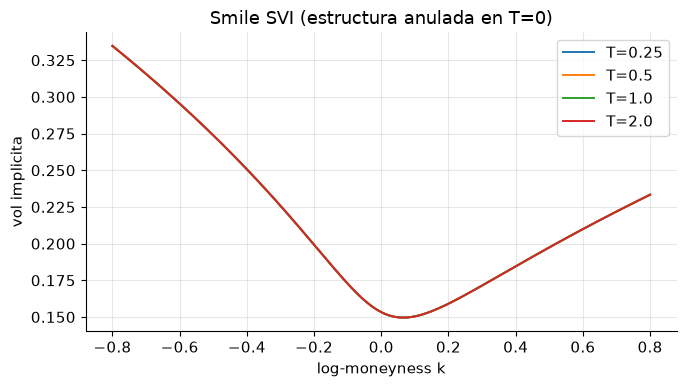

w(0,T) en T chicas (debe -> 0): T=0.01 -> 0.000235, T=0.001 -> 0.000023


In [3]:
def svi_params(T):
    a = 0.010 * T
    b = 0.09 * T
    rho = -0.4
    m = 0.0
    sigma = 0.15
    return a, b, rho, m, sigma


def w_svi(k, T):
    a, b, rho, m, sig = svi_params(T)
    return svi_total_variance(k, a=a, b=b, rho=rho, m=m, sigma=sig)


def iv_svi(K, T):
    return np.sqrt(w_svi(np.log(K / F0), T) / T)


k_grid = np.linspace(-0.8, 0.8, 161)
Ts_plot = np.array([0.25, 0.5, 1.0, 2.0])
fig, ax = plt.subplots(figsize=(7, 4))
for T in Ts_plot:
    ax.plot(k_grid, iv_svi(F0 * np.exp(k_grid), T), label=f"T={T}")
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("vol implicita")
ax.set_title("Smile SVI (estructura anulada en T=0)"); ax.legend(); fig.tight_layout(); plt.show()

print(f"w(0,T) en T chicas (debe -> 0): T=0.01 -> {w_svi(0.0, 0.01):.6f}, T=0.001 -> {w_svi(0.0, 0.001):.6f}")

### Demo 1 — vol local vs vol implícita

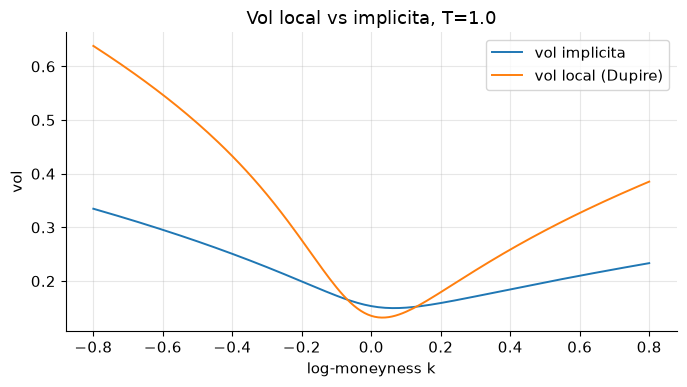

pendiente ATM (skew) implicita: -0.11744469264312052
pendiente ATM (skew) local:     -0.20749091255398144

el skew de vol LOCAL es mas pronunciado que el de vol IMPLICITA -- la regla practica
del 'factor ~2' de Dupire para el smile ATM de corto plazo.


In [4]:
T_demo = 1.0
lv_demo = dupire_local_variance(k_grid, T_demo, w_svi)
iv_demo = iv_svi(F0 * np.exp(k_grid), T_demo)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_grid, iv_demo, label="vol implicita")
ax.plot(k_grid, np.sqrt(lv_demo), label="vol local (Dupire)")
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("vol")
ax.set_title(f"Vol local vs implicita, T={T_demo}")
ax.legend(); fig.tight_layout(); plt.show()

print("pendiente ATM (skew) implicita:",
      (iv_svi(F0 * 1.01, T_demo) - iv_svi(F0 * 0.99, T_demo)) / 0.02)
print("pendiente ATM (skew) local:    ",
      (np.sqrt(dupire_local_variance(0.01, T_demo, w_svi)) - np.sqrt(dupire_local_variance(-0.01, T_demo, w_svi))) / 0.02)
print("\nel skew de vol LOCAL es mas pronunciado que el de vol IMPLICITA -- la regla practica")
print("del 'factor ~2' de Dupire para el smile ATM de corto plazo.")

### Demo 2 — Monte Carlo bajo vol local, reprecio de vainillas

In [5]:
def simulate_local_vol(K_ref_unused, T0, w_func, n_steps, n_paths, rng, dk=1e-3, dT=1e-4):
    dt = T0 / n_steps
    S = np.full(n_paths, F0)
    for i in range(n_steps):
        t = max(i * dt, 1e-4)
        k = np.log(S / F0)
        lv = np.clip(dupire_local_variance(k, t, w_func, dk=dk, dT=dT), 1e-6, 4.0)
        sig = np.sqrt(lv)
        Z = rng.standard_normal(n_paths)
        S = S * np.exp(-0.5 * sig ** 2 * dt + sig * np.sqrt(dt) * Z)
    return S


T_test = 1.0
n_steps, n_paths = 300, 150_000
strikes_test = np.array([85.0, 100.0, 115.0])

S_T = simulate_local_vol(None, T_test, w_svi, n_steps, n_paths, rng)

results = []
for K in strikes_test:
    payoff = np.maximum(S_T - K, 0.0)
    price_mc, se_mc = payoff.mean(), payoff.std() / np.sqrt(n_paths)
    price_bs = bs_price(F0, K, 0.0, 0.0, iv_svi(K, T_test), T_test, kind="call")
    z = (price_mc - price_bs) / se_mc
    results.append((K, price_mc, se_mc, price_bs, z))
    print(f"K={K}: MC={price_mc:.4f}+-{se_mc:.4f}  BS(iv mercado)={price_bs:.4f}  z={z:.2f}")

K=85.0: MC=16.8998+-0.0356  BS(iv mercado)=16.8796  z=0.57
K=100.0: MC=6.1347+-0.0265  BS(iv mercado)=6.1097  z=0.94
K=115.0: MC=1.6132+-0.0160  BS(iv mercado)=1.6057  z=0.47


## 3. Validación

In [6]:
check1 = np.allclose(lv_flat, sigma0_flat ** 2, atol=1e-10)
print(f"1. Dupire sobre superficie plana recupera exactamente sigma0: {check1}")

zs = np.array([r[4] for r in results])
check2 = np.all(np.abs(zs) <= 3.0)
print(f"2. MC (vol local) vs Black-Scholes (vol implicita de mercado), |z|<=3 en {len(strikes_test)} strikes: "
      f"{check2} (max|z|={np.max(np.abs(zs)):.2f})")

assert check1
assert check2
print("\nValidacion completa: 2/2 dentro de tolerancia.")

1. Dupire sobre superficie plana recupera exactamente sigma0: True
2. MC (vol local) vs Black-Scholes (vol implicita de mercado), |z|<=3 en 3 strikes: True (max|z|=0.94)

Validacion completa: 2/2 dentro de tolerancia.


## Referencias

- Dupire, B. (1994). *Pricing with a smile*. Risk, 7(1), 18-20.
- Gatheral, J. (2006). *The Volatility Surface: A Practitioner's Guide*, cap. 1-2.